# Overview

`x4c` attaches a `.x` accessor to `xarray.Dataset` and `xarray.DataArray` that knows
about CESM conventions: which variable holds the grid-cell areas, where latitude and
longitude live on an unstructured grid, and how the vertical coordinate is spaced.

Everything in this tutorial runs against a **reduced sample of a real case** that
ships with the docs — a Miocene 3xCO2 iCESM1.3 run on the `ne16np4` atmosphere and
`g16` ocean grids. See `README.md` in the case directory for what was trimmed.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


## Opening a file

`x4c.open_dataset` is `xarray.open_dataset` plus two things: time is always decoded
with `cftime` (so long paleo calendars and `noleap` work), and the CESM grid metadata
is attached to `ds.attrs`.

In [2]:
fpath = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)

ds = x4c.open_dataset(fpath, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
ds

<conda-env>/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 4MB
Dimensions:       (lev: 30, ilev: 31, ncol: 13826, time: 60, nbnd: 2)
Coordinates:
  * lev           (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 480B 0001-01-01 00:00:00 ... 0005-12-01 00:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/31)
    hyam          (lev) float64 240B ...
    hybm          (lev) float64 240B ...
    P0            float64 8B ...
    hyai          (ilev) float64 248B ...
    hybi          (ilev) float64 248B ...
    lat           (ncol) float64 111kB ...
    ...            ...
    n2ovmr        (time) float64 480B ...
    f11vmr        (time) float64 480B ...
    f12vmr        (time) float64 480B ...
    sol_tsi       (time) float64 480B ...
    nsteph        (time) int32 240B ...
    TS            (time, ncol) float32 3MB ...
Attributes: (12/19)
    np:               4
    ne:               16
    Conventions:      CF-1.0
    source:           CAM
    case:             b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO...
    title:            UNSET
    ...               ...
    vn:               TS
    comp:             atm
    grid:             ne16np4
    gw:               <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\n[1...
    lat:              <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13...
    lon:              <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13...

`shift_time=True` is the CESM1 convention fix: CESM writes a monthly mean with
the timestamp of the *end* of the averaging period, so January's mean is stamped
1 February. Shifting it back makes `.groupby('time.month')` and seasonal selection
mean what you expect.

## What the accessor added

The grid metadata lands in `.attrs`. `gw` is the area weight, and for an `ne16np4`
spectral-element grid it comes from the `area` variable rather than being derived
from a latitude axis — there is no latitude axis on an unstructured grid.

In [3]:
for k in ['comp', 'grid', 'vn']:
    print(f'{k:6s} = {ds.attrs[k]}')

print()
print('gw  :', ds.attrs['gw'].name, dict(ds.attrs['gw'].sizes))
print('lat :', ds.attrs['lat'].name, dict(ds.attrs['lat'].sizes))
print('lon :', ds.attrs['lon'].name, dict(ds.attrs['lon'].sizes))

comp   = atm
grid   = ne16np4
vn     = TS

gw  : area {'ncol': 13826}
lat : lat {'ncol': 13826}
lon : lon {'ncol': 13826}


## From Dataset to DataArray

`ds.x.da` returns the variable named in `ds.attrs['vn']`, carrying the grid metadata
with it. That is what makes the reductions below work on a bare `DataArray`.

In [4]:
da = ds.x.da
print(da.name, da.dims, da.shape)
print('carries gw?', 'gw' in da.attrs)
da

TS ('time', 'ncol') (60, 13826)
carries gw? True


<xarray.DataArray 'TS' (time: 60, ncol: 13826)> Size: 3MB
[829560 values with dtype=float32]
Coordinates:
  * time     (time) object 480B 0001-01-01 00:00:00 ... 0005-12-01 00:00:00
    lat      (ncol) float64 111kB ...
    lon      (ncol) float64 111kB ...
Dimensions without coordinates: ncol
Attributes:
    units:         K
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
    path:          ~/.cache/x4c/sample_data/cesm1_sample_...
    gw:            <xarray.DataArray 'area' (ncol: 13826)> Size: 111kB\narray...
    lat:           <xarray.DataArray 'lat' (ncol: 13826)> Size: 111kB\n[13826...
    lon:           <xarray.DataArray 'lon' (ncol: 13826)> Size: 111kB\n[13826...
    comp:          atm
    grid:          ne16np4

## Area-weighted means

`.x.gm` is the global area-weighted mean. On the native SE grid the weights are the
element areas, so no regridding is needed to get a correct global mean.

In [5]:
gmst = da.x.gm
print('global mean surface temperature, first 5 months (K):')
print(np.round(gmst.values[:5], 3))

print()
print('NH mean:', float(da.x.nhm[0]).__round__(3))
print('SH mean:', float(da.x.shm[0]).__round__(3))

global mean surface temperature, first 5 months (K):
[294.839 295.472 296.058 296.618 297.118]

NH mean: 289.007
SH mean: 300.502


A quick sanity check that the weighting is doing real work: the unweighted mean over
`ncol` is different, because SE elements are not equal-area.

In [6]:
weighted = float(da.isel(time=0).x.gm)
naive = float(da.isel(time=0).mean('ncol'))
print(f'area-weighted : {weighted:.4f} K')
print(f'unweighted    : {naive:.4f} K')
print(f'difference    : {weighted - naive:+.4f} K')

area-weighted : 294.8395 K
unweighted    : 294.8816 K
difference    : -0.0421 K


## A first map

`.x.plot()` dispatches on the dimensions it finds. With `ncol` present it draws the
unstructured grid directly with `tricontourf`, no regridding involved.

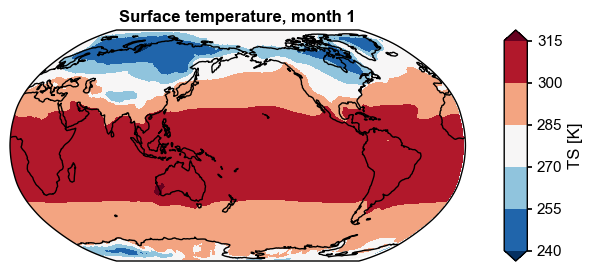

In [7]:
fig, ax = da.isel(time=0).x.plot(title='Surface temperature, month 1')
x4c.showfig(fig)

Those are *modern* coastlines drawn by Cartopy, which are wrong for a Miocene
run. [Visualization](core-visualization.ipynb) shows how to draw the model's own
coastlines instead.